## Imports
The following libraries and functions are required to run this script.

In [1]:
import os
import glob
import numpy as np
import xarray as xr
import xesmf as xe
import cf_xarray as cfxr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import font_manager
from matplotlib.colors import ListedColormap, BoundaryNorm
import io
import math
from PIL import Image, ImageDraw, ImageFont
import numpy as np

from urclimask.urban_areas import UrbanVicinity
from urclimask.utils import (
    kelvin2degC,
    fix_360_longitudes,)
from pyproj import CRS, Transformer
from shapely.affinity import translate
import sys
sys.path.append("..")
from utils.Urban_Rural_functions import variable_rural_urban, get_diurnal_cycle, get_daily_min_or_max_fields, save_figures
import textwrap
from pathlib import Path
#from utils.Urban_Rural_functions import save_figures

## Variables:
In the next cell, the input file path and name, the city name and coordinates, and the path and name of the file containing the official city boundary polygons are defined. Information such as the variable, domain, driving model, scenario, ensemble member, institution, model, version, time interval, and time period is extracted from the input file name.

The parameters and the paths to the static fields required to calculate the urban and rural masks for the selected city are also defined. Finally, an empty list is created to store the generated figures.

In [2]:
## General configuration

#City name and data info:
variable = 'huss'
driving_model = 'ERA5'
scenario = 'evaluation'
member = 'r1i1p1f1'
institution = 'BCCR-UCAN'
model = 'WRF451R-CI4C'
version = 'v1-r1'
time_period = '1hr'
data_version = 'v20240710'
city='Paris'
lon_city = 2.35
lat_city = 48.85

# Obtaination of the domain from the city_name
if city == 'Paris' or city == 'Barcelona' or city == 'Prage':
    # domain = 'ALPX-3i' 
    domain = 'ALPX-3f'#For my data, the current version is called ALPX-3i.
elif city == 'Bergen' or city == 'Hamburg' or city == 'NewCastle':
    domain = 'NSEA-3i-'


# Find files with the characteristics specified above
# data_directory = '../I4C_CPRCM_DATA/'
data_directory = '../I4C_CPRCM_CITY_DATA/'
path_list = sorted(glob.glob(f"{data_directory}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/{time_period}/{variable}/{data_version}/*{city}*.nc"))
path_input_files= '../I4C_CPRCM_DATA/'

# Path and file name of the official city boundary polygons file
city_polygon_path = '../utils/'
poligon_info_file = 'city_polygons_clean_file.gpkg'

In [3]:
path_list

['../I4C_CPRCM_CITY_DATA/ALPX-3f/BCCR-UCAN/ERA5/evaluation/r1i1p1f1/WRF451R-CI4C/v1-r1/1hr/huss/v20240710/huss_ALPX-3f_ERA5_evaluation_r1i1p1f1_BCCR-UCAN_WRF451R-CI4C_v1-r1_1hr_199901010000-199912312300_Paris_cropped_interpolated.nc',
 '../I4C_CPRCM_CITY_DATA/ALPX-3f/BCCR-UCAN/ERA5/evaluation/r1i1p1f1/WRF451R-CI4C/v1-r1/1hr/huss/v20240710/huss_ALPX-3f_ERA5_evaluation_r1i1p1f1_BCCR-UCAN_WRF451R-CI4C_v1-r1_1hr_200001010000-200012312300_Paris_cropped_interpolated.nc',
 '../I4C_CPRCM_CITY_DATA/ALPX-3f/BCCR-UCAN/ERA5/evaluation/r1i1p1f1/WRF451R-CI4C/v1-r1/1hr/huss/v20240710/huss_ALPX-3f_ERA5_evaluation_r1i1p1f1_BCCR-UCAN_WRF451R-CI4C_v1-r1_1hr_200101010000-200112312300_Paris_cropped_interpolated.nc',
 '../I4C_CPRCM_CITY_DATA/ALPX-3f/BCCR-UCAN/ERA5/evaluation/r1i1p1f1/WRF451R-CI4C/v1-r1/1hr/huss/v20240710/huss_ALPX-3f_ERA5_evaluation_r1i1p1f1_BCCR-UCAN_WRF451R-CI4C_v1-r1_1hr_200201010000-200212312300_Paris_cropped_interpolated.nc',
 '../I4C_CPRCM_CITY_DATA/ALPX-3f/BCCR-UCAN/ERA5/evaluation/r

In [4]:
##Information obtained from the file name:
# variable, domain, driving_model, scenario, member, institution, model, version, time_interval, time_period = file.split("_")

In [5]:
## Mask configuration

# Mask parameters
urban_th = 60
urban_sur_th = 15
orog_diff = 100
sftlf_th = 70
ratio_r2u = 1  # Rural cell number per urban one
min_city_size = 80  # Minimum number of grid points required for the city
lon_lim = 0.7
lat_lim = 0.7

domain_resolution = int(domain.split("-")[1][:-1])  # In km
urban_var = 'sfturf'  # Name of the urban-rural field introduced in the model

file_sfturf = glob.glob(f"{path_input_files}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/fx/sfturf/*/*.nc")
file_orog = glob.glob(f"{path_input_files}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/fx/orog/*/*.nc")
file_sftlf = glob.glob(f"{path_input_files}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/fx/sftlf/*/*.nc")

#---------------------------------------------------
# #Substitude the 3 lines above while in local path:
# file_sfturf = '../utils/sfturf_ALPX-3f_ERA5_evaluation_r1i1p1f1_BCCR-UCAN_WRF451R-CI4C_v1-r1_fx.nc'
# file_orog = '../utils/orog_ALPX-3f_ERA5_evaluation_r1i1p1f1_BCCR-UCAN_WRF451R-CI4C_v1-r1_fx.nc'
# file_sftlf = '../utils/sftlf_ALPX-3f_ERA5_evaluation_r1i1p1f1_BCCR-UCAN_WRF451R-CI4C_v1-r1_fx.nc'


In [6]:
# List to save figures:
figures = [] 

## Mask

### Mask obtention

First, an output directory is created to store the mask files if it does not already exist.

The path and name of the mask file are then defined. The code checks whether a mask already exists for the selected city, domain, and model. If the file exists, it is loaded directly. Otherwise, the urban–rural mask is calculated and saved.

To calculate the mask, the static model fields containing the urban fraction, orography, and land fraction are opened. The `fix_360_longitudes` function from the `urclimask` repository is then applied to these datasets. This function checks whether the longitude coordinates use the 0°–360° convention and, when necessary, converts them to the −180°–180° range.

Next, an object of the `UrbanVicinity` class is created using the previously defined mask parameters and city information. The static fields are cropped to an area surrounding the selected city, and the intermediate urban, urban-surroundings, orography, and land-fraction masks are calculated.

The final urban–rural mask is obtained by progressively expanding the area around the city until enough suitable rural grid cells are found. Sea grid cells and areas with non-comparable orography are excluded from the rural selection.

Finally, the resulting mask is converted into an `xarray.Dataset`. The coordinate reference system information is added to the dataset so that the mask can be correctly represented later, and the result is saved as a NetCDF file.


In [7]:
#Folder to save masks
output_dir = '../utils/urclimask_Results'# Name of the output directory
os.makedirs(output_dir, exist_ok = True) #The directory is only created if it does'nt exist

In [8]:
path_name_mask = f"{output_dir}/{city}-{domain}_{model}_urban_rural_mask.nc" #Masks file names

if os.path.isfile(path_name_mask):
    print("The mask already exists")
    urmask = xr.open_dataset(path_name_mask)
else:
    #Open fields datasets
    ds_sfturf = xr.open_dataset(file_sfturf[0])
    ds_orog = xr.open_dataset(file_orog[0])
    ds_sftlf = xr.open_dataset(file_sftlf[0])

    #---------------------------------------------------
    # #Local path-Replace the 3 lines above
    # ds_sfturf = xr.open_dataset(file_sfturf)
    # ds_orog = xr.open_dataset(file_orog)
    # ds_sftlf = xr.open_dataset(file_sftlf)
    #---------------------------------------------------

    ds_sfturf = fix_360_longitudes(ds_sfturf)#Repository's urclimask function. It's defined in urclimask/utils.py. 
                                            #It converts longitudes from 0–360° to -180–180°
    ds_orog = fix_360_longitudes(ds_orog)
    ds_sftlf = fix_360_longitudes(ds_sftlf)

    #It creates the object urban from UrbanVicinity (urclimask repository)
    URBAN = UrbanVicinity(
        urban_sur_th = urban_sur_th,
        orog_diff = orog_diff,
        sftlf_th = sftlf_th,
        ratio_r2u = ratio_r2u,
        min_city_size = min_city_size,
        lon_city = lon_city,
        lat_city = lat_city,
        lon_lim = lon_lim,
        lat_lim = lat_lim,
        model = model,
        domain = domain,
        urban_th = urban_th,
        urban_var = urban_var
    )

    # Crop area around the city in the fields datasets
    ds_sfturf = URBAN.crop_area_city(ds = ds_sfturf, res = domain_resolution)
    ds_orog = URBAN.crop_area_city(ds = ds_orog, res = domain_resolution)
    ds_sftlf = URBAN.crop_area_city(ds = ds_sftlf, res = domain_resolution)

    # Define masks using the parameters above
    sfturf_mask, sfturf_sur_mask, orog_mask, sftlf_mask = URBAN.define_masks(
        ds_sfturf = ds_sfturf, #
        ds_orog = ds_orog, 
        ds_sftlf = ds_sftlf,
    )

    # sfturf_mask: Urban mask, identifies urban grid cells based on the urban variable (sftimf) and the defined urban threshold (urban_th).
    # sfturf_sur_mask: Urban surroundings mask, identifies grid cells in the transition zone between urban and rural areas based on the urban surface threshold (urban_sur_th).
    # orog_mask: Orography mask, identifies grid cells where the elevation difference is less than the defined threshold (orog_diff). 

    ## Final rural-urban mask:
    # Starting from the city, it progressively expands the surrounding area until it finds enough comparable rural cells, 
    # excluding sea, areas with non-comparable orography, and peri-urban zones.
    urmask = URBAN.select_urban_vicinity(
        sfturf_mask = sfturf_mask, 
        orog_mask = orog_mask,
        sftlf_mask = sftlf_mask,
        sfturf_sur_mask = sfturf_sur_mask
    )
    #ratio_r2u-> Criteria for enough riral cells, predefined (self)

    ##Save the mask in a netcdf file
    urmask.urmask.to_netcdf(path_name_mask)

    ##Save the mask with the information of the coordinates:
    # mask_dataset = urmask.urmask.to_dataset(name="urmask")
    # mask_dataset["crs"] = xr.DataArray(0,attrs=ds_sfturf["crs"].attrs)
    # mask_dataset["urmask"].attrs["grid_mapping"] = "crs"
    # mask_dataset.to_netcdf(path_name_mask)
    

    print("The file did not exist, so it was calculated and saved.")
    

The mask already exists


In [9]:
urmask

<xarray.Dataset> Size: 61kB
Dimensions:  (y: 50, x: 50)
Coordinates:
  * y        (y) float64 400B 2.385e+05 2.415e+05 ... 3.825e+05 3.855e+05
  * x        (x) float64 400B -2.235e+05 -2.205e+05 ... -7.95e+04 -7.65e+04
    lon      (y, x) float64 20kB ...
    lat      (y, x) float64 20kB ...
Data variables:
    urmask   (y, x) float64 20kB ...
    crs      int64 8B ...

### Urban–rural mask and official city boundary

First, the file containing the official city boundary polygons is read. The polygon corresponding to the selected city is then extracted and stored in the matches variable.

Next, two colors are assigned to the urban–rural mask: blue for rural grid cells and red for urban grid cells. Since the city boundary and the mask use different coordinate reference systems, the projection information stored in the mask is used to transform the city polygon to the model-grid projection.

The offset between the projected longitude–latitude coordinates and the x and y coordinates stored in the mask is then calculated. This offset is applied to the city polygon so that it is correctly aligned with the model grid.

Finally, the urban–rural mask and the official city boundary are represented in the same figure, and the figure is added to the list of generated figures.

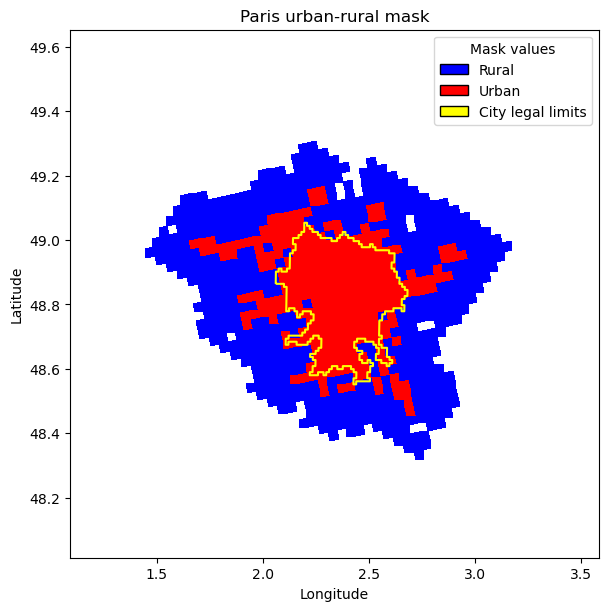

In [10]:
##City poligon extraction:

#Read file
gdf = gpd.read_file(city_polygon_path+poligon_info_file)

# #clean the geopandas file: Only did it onces.
# # Remove \ufeff from colum names
# ucdb_info .columns = [col.lstrip("\ufeff") for col in ucdb_info.columns]
# # Save the clean file:
# ucdb_info .to_file("archivo_limpio.gpkg", driver="GPKG")#to save as geopandas file

#Find the city in the file:
matches = gdf[gdf["GC_UCN_MAI_2025"].astype(str).str.contains(city, case=False, na=False)]

#-----------------------------
## Mask representation with the polygon: 

# 0 = rural, 1 = urban
cmap = ListedColormap(["blue", "red"])
norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

urmask.urmask.plot(ax=ax, x="lon", y="lat", cmap=cmap, norm=norm, add_colorbar=False)

# Plot the GeoDataFrame over the mask
matches = matches.to_crs(epsg=4326)
matches.boundary.plot(ax=ax, facecolor="none", edgecolor="yellow", linewidth=1.5, zorder=3)

ax.set_title(f"{city} urban-rural mask")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

legend_elements = [
    mpatches.Patch(facecolor="blue", edgecolor="black", label="Rural"),
    mpatches.Patch(facecolor="red", edgecolor="black", label="Urban"),
    mpatches.Patch(facecolor="yellow", edgecolor="black", label="City legal limits")
]
ax.legend(handles=legend_elements, title="Mask values", loc="upper right")

plt.show()
figures.append(fig)

### Interpolating the mask onto the data grid

In [11]:
## target grid:
from utils.DestinyGridParameters import newlonlat_city  # Import the function that defines the target grid for each city
#Calculate the I4C grid for the city according the GitHub repository and save the grid parameters:
new_longitude, new_latitude, x_first, xend, x_size, y_size, x_increment, y_increment, y_first, yend = newlonlat_city(city)
#New_longitude and new_latitude already have the limits expanded

# Define the target grid as a dataset: Necessary for xESMF regridding
ds_out = xr.Dataset(coords={ "lon": ("lon", new_longitude), "lat": ("lat", new_latitude)})

# Source grid of the mask (2D lat/lon coordinates)
ds_in_mask = xr.Dataset({"lon": urmask["lon"], "lat": urmask["lat"],})

# Mask-specific regridder (nearest-neighbor, not bilinear)
regridder_mask = xe.Regridder(
    ds_in_mask, ds_out, 
    method="nearest_s2d", #better for masks instead of bilinear
    periodic=False, 
    ignore_degenerate=True)

# Apply the regridder
urmask_regridded = regridder_mask(urmask[["urmask"]])

#Cut the mask to the targed domain
urmask_regridded = urmask_regridded.sel(
    lon=slice(x_first, xend),
    lat=slice(y_first, yend))

{'gridtype': 'lonlat', 'xsize': 89, 'ysize': 59, 'xfirst': 0.828125, 'xinc': 0.03125, 'yfirst': 47.921875, 'yinc': 0.03125}
(152,) (122,)


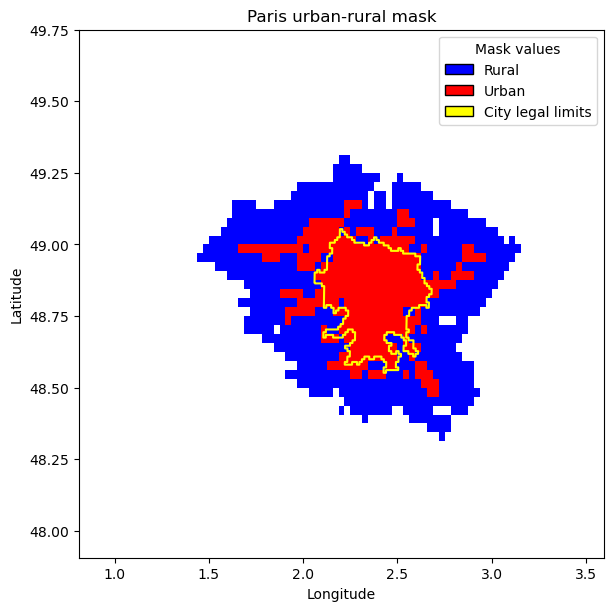

In [12]:
## Mask representation after the interpolation:

## Mask representation with the polygon: 

# 0 = rural, 1 = urban
cmap = ListedColormap(["blue", "red"])
norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

urmask_regridded.urmask.plot(ax=ax, x="lon", y="lat", cmap=cmap, norm=norm, add_colorbar=False)

# Plot the GeoDataFrame over the mask
matches = matches.to_crs(epsg=4326)
matches.boundary.plot(ax=ax, facecolor="none", edgecolor="yellow", linewidth=1.5, zorder=3)

ax.set_title(f"{city} urban-rural mask")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

legend_elements = [
    mpatches.Patch(facecolor="blue", edgecolor="black", label="Rural"),
    mpatches.Patch(facecolor="red", edgecolor="black", label="Urban"),
    mpatches.Patch(facecolor="yellow", edgecolor="black", label="City legal limits")
]
ax.legend(handles=legend_elements, title="Mask values", loc="upper right")

plt.show()
figures.append(fig)

In [13]:
# Save interpolated mask:
path_name_mask = f"{output_dir}/{city}_{domain}_{model}_urban_rural_regridded_mask.nc" #Masks file names
urmask_regridded.urmask.to_netcdf(path_name_mask)

## Heat/hummidity island and diurnal cycles:

In the following section, the data from the input file are analysed for the summer months: June, July, and August (JJA).

First, a map showing the variable averaged over the selected period is generated, and the mean urban heat or humidity island is calculated. The mean urban and rural diurnal cycles, together with their difference, are also obtained for the summer period.

Additional analyses are performed depending on the variable. For temperature variables, the fields corresponding to the daily minimum and maximum mean temperatures are selected. For humidity variables, the field at 12:00 is selected as an approximation of the daily minimum humidity. For each case, a mean map and the corresponding urban–rural difference are calculated. Diurnal cycles are not obtained for these additional analyses because only one field or time step is retained for each day.

### Summer: heat/hummidity island and diurnal cycles:

#### Read data:
First, the input dataset is opened. The selected variable is converted from Kelvin to degrees Celsius, and the longitude coordinates are converted from the 0°–360° range to the −180°–180° range when necessary.

The urban–rural mask is then used to separately select the variable values corresponding to urban and rural grid cells.

In [14]:
#Read data

ds = xr.open_dataset('data/' + variable + '_' + domain + '_' + driving_model + '_' + scenario + '_' + member + '_' + institution + '_' + model + '_' + version + '_' + time_period + '_' + city + '_cropped_interpolated.nc')

#-------------to dataset before regridging: revise----------------
# datasets = []

# for path in sorted(path_list):
#     ds_aux = xr.open_dataset(path)

#     # Convert all time coordinates to the same calendar and datetime64 type
#     if ds_aux.indexes["time"].__class__.__name__ == "CFTimeIndex":
#         ds_aux = ds_aux.convert_calendar(
#             "proleptic_gregorian",
#             use_cftime=False
#         )

#     # Remove auxiliary bounds if they conflict between files
#     ds_aux = ds_aux.drop_vars(
#         ["lon_bnds", "lat_bnds"],
#         errors="ignore"
#     )

#     datasets.append(ds_aux)

# ds = xr.concat(
#     datasets,
#     dim="time",
#     data_vars="minimal",
#     coords="minimal",
#     compat="equals",
#     join="exact"
# ).sortby("time")
#--------------------------------

#Convert Kelvin degrees to celsius:
ds = kelvin2degC(ds, variable)#K->ºC

#Fix longitudes if it's necessary
ds = fix_360_longitudes(ds)#0–360 -> -180–180

#Selection of urban grid cells:
urban_mask = urmask_regridded.urmask == 1 #Urban mask definition

variable_city = ds[variable].where(urban_mask)

# Selection of the rural grid cells:
# rural_mask = urmask.urmask == 0#Rural mask definition
rural_mask = urmask_regridded.urmask == 0
variable_rural = ds[variable].where(rural_mask)

#### Summer period selection:

If required, the time coordinate can first be converted to the datetime64 format. The data corresponding to the summer months ( June, July, and August (JJA) ) are then selected separately for the urban and rural grid cells.

In [15]:
# Transform time to datetime the date coordinate if necessary
# variable_city = variable_city.assign_coords(
#     time=np.array([
#         np.datetime64(f"{t.year:04d}-{t.month:02d}-{t.day:02d}T{t.hour:02d}:{t.minute:02d}:{t.second:02d}")
#         for t in variable_city.time.values]))

# variable_rural = variable_rural.assign_coords(
    # time=np.array([
    #     np.datetime64(f"{t.year:04d}-{t.month:02d}-{t.day:02d}T{t.hour:02d}:{t.minute:02d}:{t.second:02d}")
    #     for t in variable_rural.time.values]))

#Obtain the summer months (June, July, August)
season_months = [6, 7, 8]
season_variable_city = variable_city.sel(time=variable_city.time.dt.month.isin(season_months))
season_variable_rural = variable_rural.sel(time=variable_rural.time.dt.month.isin(season_months))

season_variable_rural.attrs["extreme_type"] = "all data"
season_variable_city.attrs["extreme_type"] = "all data"

In [16]:
print("season_variable_city" in globals())
print("season_variable_rural" in globals())

True
True


#### Urban and rural variable mean values representation 

A figure is generated to represent the mean value of the selected variable over the summer period for the urban and rural grid cells.

The variable_rural_urban function from Urban_Rural_functions is used for this purpose. Inside the function, the time mean is calculated separately for the urban and rural data. Both fields are then represented on the same map using a common colour scale, so that their values can be compared directly.

Finally, the urban–rural mask boundary is added as a contour line, and the resulting figure is appended to the list of generated figures.

In [17]:
months = np.unique(season_variable_city.time.dt.month.values)
print(months)
import calendar

month_names = [calendar.month_name[month] for month in months]
month_names_text = ", ".join(month_names)
print(month_names_text)


[6 7 8]
June, July, August


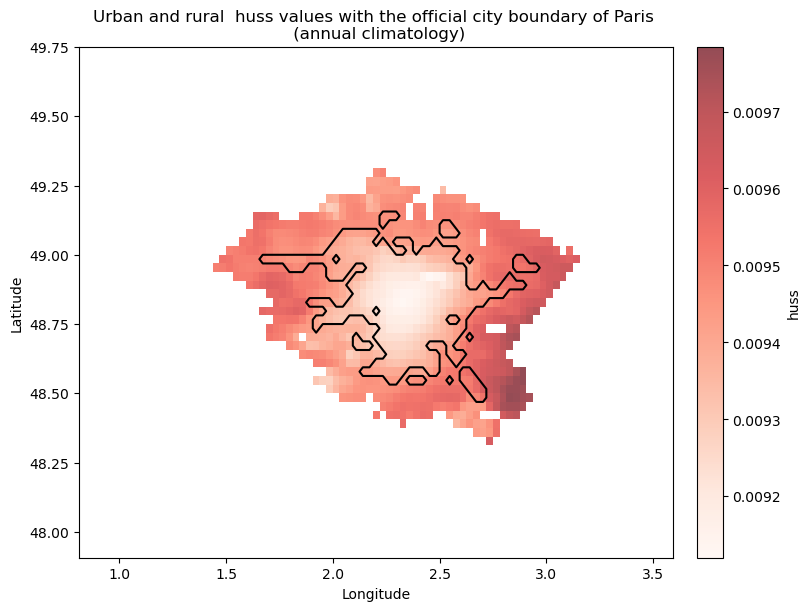

In [18]:
# fig=variable_rural_urban(season_variable_city, season_variable_rural, '(summer mean)', urmask, variable, city)
fig=variable_rural_urban(season_variable_city, season_variable_rural, urmask_regridded, variable, city)
figures.append(fig)

#### Diurnal cycle:

The mean diurnal cycles of the selected variable are calculated separately for the urban and rural areas using the get_diurnal_cycle function.

First, the function calculates the spatial mean over all urban or rural grid cells. The resulting values are then grouped by hour of the day and averaged over the entire summer period. This produces one mean value for each available hour.

Finally, the urban and rural diurnal cycles are represented in the same figure to allow their direct comparison, and the figure is appended to the list of generated figures.

In [19]:
season_variable_city

<xarray.DataArray 'huss' (time: 30912, lat: 59, lon: 89)> Size: 649MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(30912, 59, 89), dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 247kB 1999-06-01 ... 2023-08-31T23:00:00
  * lat      (lat) float64 472B 47.92 47.95 47.98 48.02 ... 49.67 49.7 49.73
  * lon      (lon) float64 712B 0.8281 0.8594 0.8906 ... 3.516 3.547 3.578
Attributes:
    standard_name:  specific_humidity
    long_name:      Near-Surface Specific Humidity
    units:          1
    cell_methods:   time: point
    grid_mapping:   crs
    extreme_type:   all data

In [20]:
print(season_variable_city.attrs)

{'standard_name': 'specific_humidity', 'long_name': 'Near-Surface Specific Humidity', 'units': '1', 'cell_methods': 'time: point', 'grid_mapping': 'crs', 'extreme_type': 'all data'}


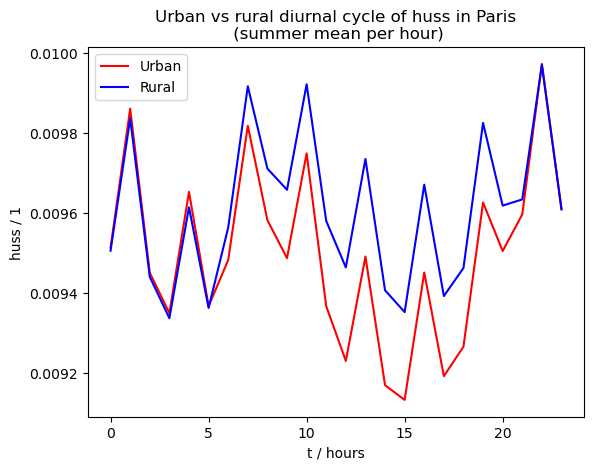

In [21]:
#Obtention of the diurnal cycle for urban and rural areas
season_urban_cycle = get_diurnal_cycle(season_variable_city)
season_rural_cycle = get_diurnal_cycle(season_variable_rural)

#Figure
fig, ax = plt.subplots()

season_urban_cycle.plot(ax=ax, label="Urban", color="red")
season_rural_cycle.plot(ax=ax, label="Rural", color="blue")

ax.set_title(f"Urban vs rural diurnal cycle of {variable} in {city}\n (summer mean per hour)")
ax.set_xlabel("t / hours")
ax.set_ylabel(f"{variable} / {season_urban_cycle.attrs['units']}")
ax.legend()

figures.append(fig)
plt.show()

The difference between the urban and rural diurnal cycles is then calculated by subtracting the rural cycle from the urban cycle for each hour of the day.

The resulting hourly difference is represented in a separate figure, which shows how the urban–rural difference evolves throughout the mean summer day. Finally, the figure is appended to the list of generated figures.

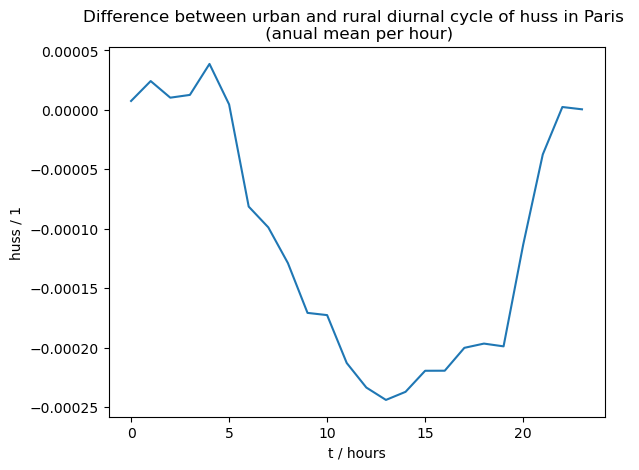

In [22]:
##DIFFERENCE BETWEEN URBAN AND RURAL DIURNAL CYCLE:
diurnal_cycle_diff=season_urban_cycle-season_rural_cycle
diurnal_cycle_diff.plot()
plt.title(f"Difference between urban and rural diurnal cycle of {variable} in {city} \n (anual mean per hour)")
plt.xlabel('t / hours')
plt.ylabel(f"{variable} / {season_urban_cycle.attrs['units']}")
figures.append(plt.gcf())

### Summer minimum variable:  heat/hummidity island and diurnal cycles

#### Obtain the minimum variable values

For temperature variables, the get_daily_min_or_max_fields function is used to select one complete spatial field per day. First, the spatial mean temperature is calculated at each time step. The function then identifies the time at which this mean reaches its daily minimum and retains the complete temperature field corresponding to that time. This procedure is applied separately to the urban and rural data.

For humidity variables, the urban and rural fields corresponding to a fixed hour of the day are selected as an approximation of the daily minimum humidity.

In [23]:
# # if variable == 'tas':
# if variable == 'ta1000':
#     #If the variable is temperature, we calculate the daily minimum fields for urban and rural areas in summer
#     var_min_season_variable_rural = get_daily_min_or_max_fields(season_variable_rural, 'minimum')
#     var_min_season_variable_city = get_daily_min_or_max_fields(season_variable_city, 'minimum')
# elif variable == 'huss':
#     #If the variable is humidity, we select the temperature at 12:00 AM
#     var_min_season_variable_rural = season_variable_rural.sel(time=season_variable_rural.time.dt.hour == 0)
#     var_min_season_variable_city = season_variable_city.sel(time=season_variable_city.time.dt.hour == 0)
var_min_season_variable_rural = get_daily_min_or_max_fields(season_variable_rural, 'minimum')
var_min_season_variable_city = get_daily_min_or_max_fields(season_variable_city, 'minimum')

#Atribute od extreme type assignation:
var_min_season_variable_rural.attrs["extreme_type"] = "min"
var_min_season_variable_city.attrs["extreme_type"] = "min"

#### Urban and rural variable mean values representation 
The mean urban and rural fields for the previously selected daily conditions are represented using the variable_rural_urban function. The resulting figure is appended to the list of generated figures.

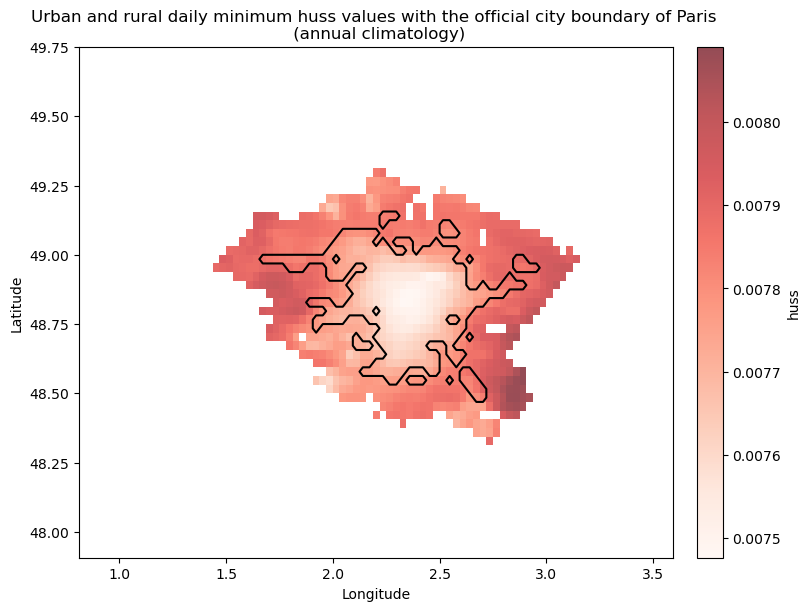

In [24]:
fig=variable_rural_urban(var_min_season_variable_city, var_min_season_variable_rural, urmask_regridded, variable, city)
figures.append(fig)

#### There isn`t diurnal cycle for the minimum values

### Summer maximun variable:  heat/hummidity island and diurnal cycles

#### Obtain the maximum variable values
For temperature variables, the complete spatial fields corresponding to the daily maximum spatial mean temperature are selected separately for the urban and rural areas. For humidity variables, no maximum field is defined.

In [25]:
# if variable == 'ta1000':
#     #If the variable is temperature, we calculate the daily minimum fields for urban and rural areas in summer
#     var_max_season_variable_rural = get_daily_min_or_max_fields(season_variable_rural, 'maximum')
#     var_max_season_variable_city = get_daily_min_or_max_fields(season_variable_city, 'maximum')
# elif variable == 'huss':
#     print('Humidity maximum not defined')

var_max_season_variable_rural = get_daily_min_or_max_fields(season_variable_rural, 'maximum')
var_max_season_variable_city = get_daily_min_or_max_fields(season_variable_city, 'maximum')

#Atribute od extreme type assignation:
var_max_season_variable_rural.attrs["extreme_type"] = "max"
var_max_season_variable_city.attrs["extreme_type"] = "max"

#### Urban and rural variable mean values representation 

The mean urban and rural fields corresponding to the selected daily maximum temperature conditions are represented, and the resulting figure is appended to the list of generated figures.

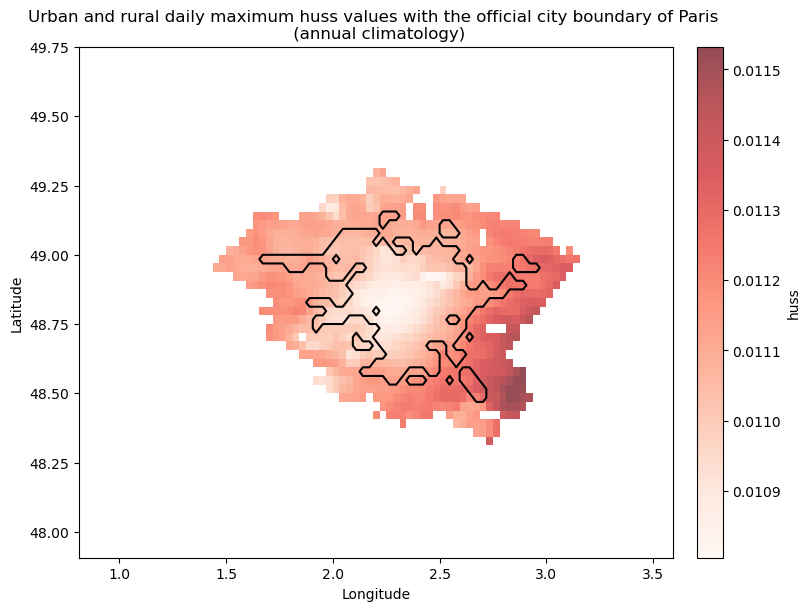

In [26]:
fig=variable_rural_urban(var_max_season_variable_city, var_max_season_variable_rural, urmask_regridded, variable, city)
figures.append(fig)

#### There isn`t diurnal cycle for the maximum values

## Save figures

The figures generated in the previous sections are first assigned to specific positions in a grid. Each figure is associated with a row and a column, which determines its location in the final combined image.

The type of urban island is then defined according to the analysed variable: heat island for temperature and humidity island for specific humidity. A summary text is also created containing the input file name, the variable, and the urban–rural differences calculated for the complete summer period and for the selected daily minimum and maximum conditions.

The save_figures function is used to create the final image. This function converts each Matplotlib figure into an image, determines a common cell size, and places the figures in their specified grid positions. Figures smaller than the grid cells are centred within them.

The summary text is added below the grid when provided. Finally, the output directory is created if necessary, and the complete image is saved using a file name containing the main information extracted from the input data.

In [27]:
# Use save_figure for saving figure

positioned_figures = [
         (figures[1], 0, 0),
         (figures[3], 1, 0),
         (figures[4], 2, 0),
         (figures[2], 0, 1),
         (figures[5], 1, 1),
         (figures[6], 2, 1),]
# if variable == 'tas':
#     island_type ='Heat'
# elif variable == 'huss':
#     island_type ='Humidity'
# else:
#     print('Incorrect variable')


info_text = (
    f"Files: {data_directory}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/{time_period}/{variable}/{data_version}/*{city}*.nc\n" 
    # f"Period: {poner_variable de años}\n"
    # f"Variable: {variable}\n"
    # f"Urban {island_type} Island values:\n"
    # f" - Summer: {summer_dif:.2f}\n"
    # f" - Summer daily minimum: {summer_min_dif:.2f}\n"
    # f" - Summer daily maximum: {summer_max_dif:.2f}\n"
    )

#Path and file name for the final image:
output_dir2 = (Path("../utils/urban_rural_mask_and_diurnal_cycle_figures"))
output_path = (output_dir2 / f"{domain}_{driving_model}_{scenario}_{member}_{institution}_{model}_{version}_{variable}_urban_rural_mask_and_diurnal_cycle.png")

combined = save_figures(
    positioned_figures,
    output_path,
    info_text,)